In [208]:
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


import pandas as pd
import seaborn as sns

## Superoperator analysis from .npz files for different $\alpha$

In [ ]:
# (npz-number, alpha)

file_numbers = [(11, .25),
                (12, .50),
                (13, .75),
                (14, 1.)]

suffix = '_normalized'

In [ ]:
frames = []
N_sweeps = len(file_numbers)

for nbr, alpha in file_numbers:
    path = Path(f"data/superoperator_N4_h_sweep_{nbr}.npz")  # reused files, relabeled as sigma
    data = np.load(path)

    df = pd.DataFrame({
        "h_over_J": data["h_over_J"],
        "Delta2": data["Delta2"],
        "Delta_th": data["Delta_th"],
        "num_closer": data["num_closer"],
        "trace_distance": data["trace_distance"],
        "get_mixingtime": data["get_mixingtime"],
    })
    df["alpha"] = alpha

    frames.append(df)

ha_data = pd.concat(frames, ignore_index=True)

mix_grid = ha_data.pivot(index="h_over_J", columns="alpha", values="get_mixingtime").sort_index().sort_index(axis=1)
gap_grid = ha_data.pivot(index="h_over_J", columns="alpha", values="Delta2").sort_index().sort_index(axis=1)
tr_grid = ha_data.pivot(index="h_over_J", columns="alpha", values="trace_distance").sort_index().sort_index(axis=1)

h_vals = mix_grid.index.to_numpy()
alpha_vals = mix_grid.columns.to_numpy()
values = ["mixingtime", "Delta2", "trace_distance"]

Y = np.stack([
    mix_grid.to_numpy(),
    gap_grid.to_numpy(),
    tr_grid.to_numpy(),
], axis=1)

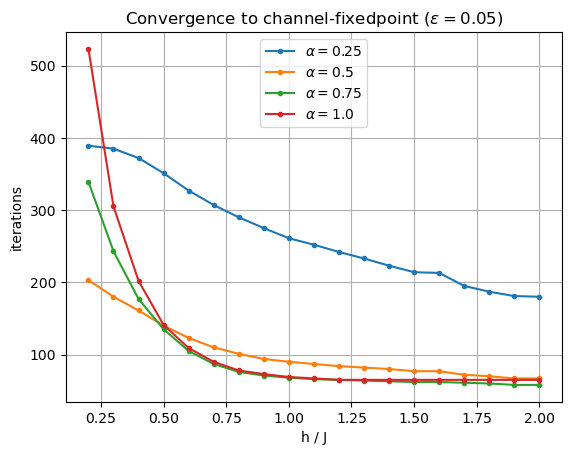

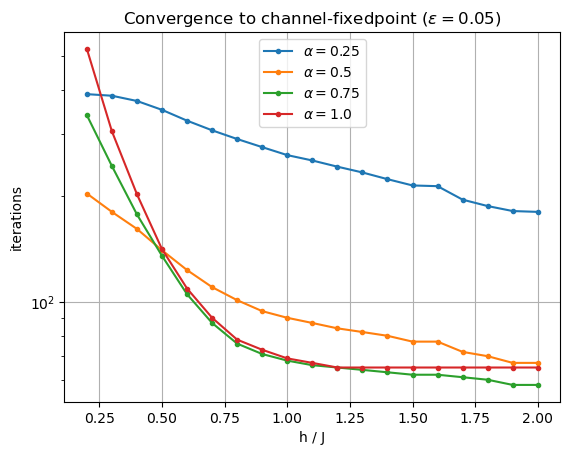

In [ ]:
for alpha_idx in range(0, N_sweeps):
    x = h_vals[1:]
    y0 = Y[1:, 0, alpha_idx]
    plt.plot(x, y0, label=rf"$\alpha = {alpha_vals[alpha_idx]}$", marker=".")
    plt.legend(loc="upper center")
    plt.xlabel("h / J")
    plt.ylabel("iterations")
    plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
    plt.grid(True)
    plt.savefig("docu/iterations"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

for alpha_idx in range(0, N_sweeps):
    x = h_vals[1:]
    y0 = Y[1:, 0, alpha_idx]
    plt.semilogy(x, y0, label=rf"$\alpha = {alpha_vals[alpha_idx]}$", marker=".")
    plt.legend(loc="upper center")
    plt.xlabel("h / J")
    plt.ylabel("iterations")
    plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
    plt.grid(True)
    plt.savefig("docu/iterations_log"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

'\nlabels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]\nymin, ymax = 0., 0.05\npos=[[0,0],[0,1],[1,0],[1,1]]\n\nfig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)\n\n\nfor i, sigma in enumerate(ha_data["alpha"].unique()):\n    ax = axs[pos[i][0], pos[i][1]]\n    subset = ha_data[ha_data["alpha"] == sigma].sort_values("h_over_J")\n\n    sns.barplot(data=subset, x="h_over_J", y="Delta2", hue="alpha", dodge=True, palette="tab10", ax=ax)\n\n    ax.set_title(rf"$\x07lpha = {sigma}$")\n    ax.set_xlabel("h / J")\n    ax.set_ylabel(r"$\\Delta_2$")\n    ax.legend(title=r"$\x07lpha$")\n    ax.set_ylim(ymin, ymax)\n\n    ax.set_xticks(ticks[1::2])\n    ax.set_xticklabels(labels[1::2])\n    plt.tight_layout()\nplt.show()\n'

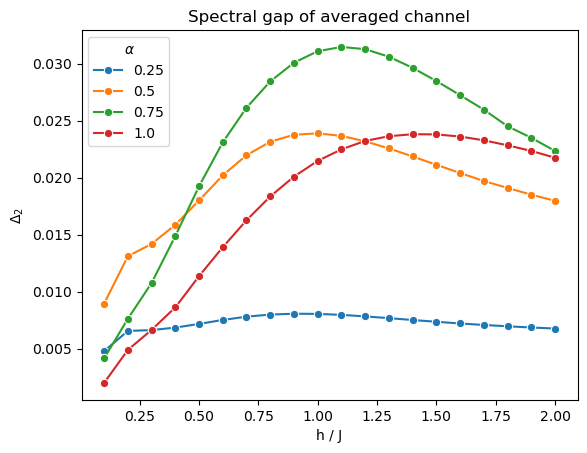

In [ ]:
#ax = sns.barplot(data=ha_data, x="h_over_J", y="Delta2", hue="alpha", dodge=True, palette="tab10")
ax = sns.lineplot(data=ha_data, x="h_over_J", y="Delta2", hue="alpha", marker="o", palette="tab10")

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\Delta_2$")

ax.set_title("Spectral gap of averaged channel")
plt.legend(title=rf"$\alpha$")
plt.grid(True)
ax.figure.savefig("docu/gap"+suffix+".png", dpi=300, bbox_inches="tight")

'''
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]
ymin, ymax = 0., 0.05
pos=[[0,0],[0,1],[1,0],[1,1]]

fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)


for i, sigma in enumerate(ha_data["alpha"].unique()):
    ax = axs[pos[i][0], pos[i][1]]
    subset = ha_data[ha_data["alpha"] == sigma].sort_values("h_over_J")

    sns.barplot(data=subset, x="h_over_J", y="Delta2", hue="alpha", dodge=True, palette="tab10", ax=ax)

    ax.set_title(rf"$\alpha = {sigma}$")
    ax.set_xlabel("h / J")
    ax.set_ylabel(r"$\Delta_2$")
    ax.legend(title=r"$\alpha$")
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(ticks[1::2])
    ax.set_xticklabels(labels[1::2])
    plt.tight_layout()
plt.show()
'''

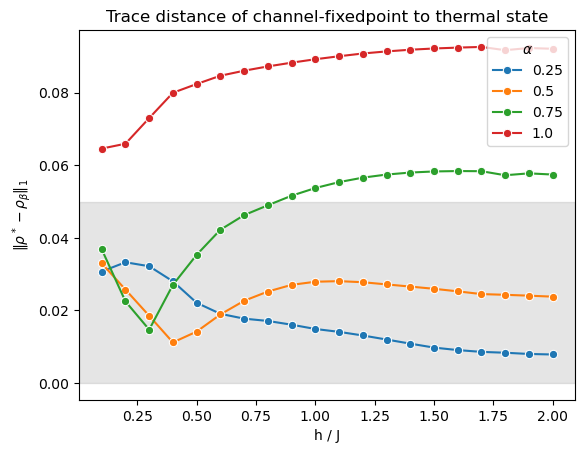

In [ ]:
#ax = sns.barplot(data=ha_data, x="h_over_J", y="trace_distance", hue="alpha", dodge=True, palette="tab10")
ax = sns.lineplot(data=ha_data, x="h_over_J", y="trace_distance", hue="alpha", marker="o", palette="tab10")


ax.axhspan(0, 0.05, color="gray", alpha=0.2)

ticks = ax.get_xticks()
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]

#ax.set_xticks(ticks[1::2])
#ax.set_xticklabels(labels[1::2])

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\|\rho^*-\rho_{{\beta}}\|_1$")
ax.set_title("Trace distance of channel-fixedpoint to thermal state")
plt.legend(title=rf"$\alpha$", loc=1)
ax.grid(True, axis="y", which="both")
ax.figure.savefig("docu/distance_to_gibbs"+suffix+".png", dpi=300, bbox_inches="tight")

## Superoperator analysis from .npz files for different $\sigma$

In [266]:
# (npz-number, alpha)

file_numbers = [(15, .5),
                (16, 1.),
                (17, 2.),
                (18, 4.),
                (19, 3.)]

suffix = '_sigma'

In [267]:
frames = []
N_sweeps = len(file_numbers)

for nbr, sigma in file_numbers:
    path = Path(f"data/superoperator_N4_h_sweep_{nbr}.npz")  # reused files, relabeled as sigma
    data = np.load(path)

    df = pd.DataFrame({
        "h_over_J": data["h_over_J"],
        "Delta2": data["Delta2"],
        "Delta_th": data["Delta_th"],
        "num_closer": data["num_closer"],
        "trace_distance": data["trace_distance"],
        "get_mixingtime": data["get_mixingtime"],
    })
    df["sigma"] = sigma
    frames.append(df)

ha_data = pd.concat(frames, ignore_index=True)

mix_grid = ha_data.pivot(index="h_over_J", columns="sigma", values="get_mixingtime").sort_index().sort_index(axis=1)
gap_grid = ha_data.pivot(index="h_over_J", columns="sigma", values="Delta2").sort_index().sort_index(axis=1)
tr_grid = ha_data.pivot(index="h_over_J", columns="sigma", values="trace_distance").sort_index().sort_index(axis=1)

h_vals = mix_grid.index.to_numpy()
sigma_vals = mix_grid.columns.to_numpy()
values = ["mixingtime", "Delta2", "trace_distance"]

Y = np.stack([
    mix_grid.to_numpy(),
    gap_grid.to_numpy(),
    tr_grid.to_numpy(),
], axis=1)

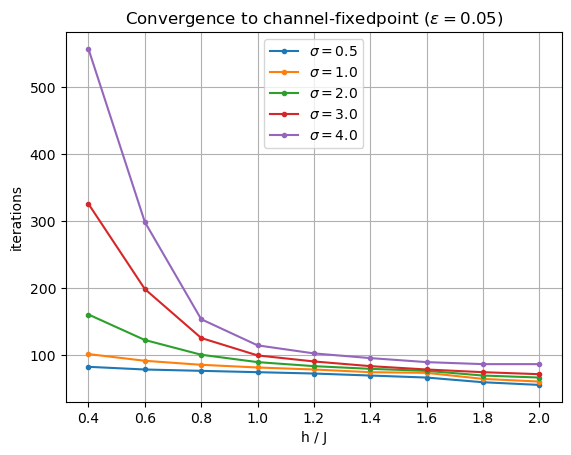

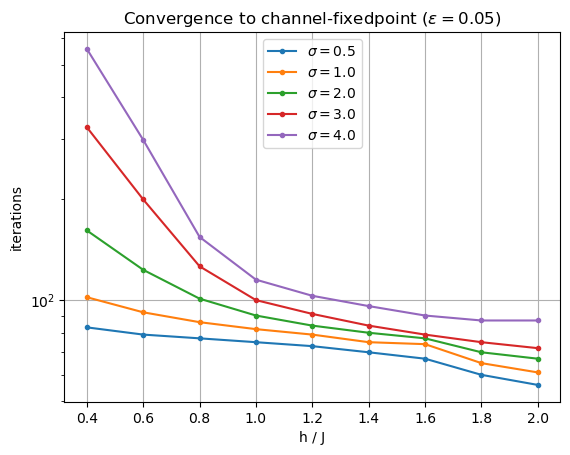

In [268]:
for sigma_idx in range(0, N_sweeps):
    x = h_vals[1:]
    y0 = Y[1:, 0, sigma_idx]
    plt.plot(x, y0, label=rf"$\sigma = {sigma_vals[sigma_idx]}$", marker=".")
    plt.legend(loc="upper center")
    plt.xlabel("h / J")
    plt.ylabel("iterations")
    plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
    plt.grid(True)
    plt.savefig("docu/iterations"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

for sigma_idx in range(0, N_sweeps):
    x = h_vals[1:]
    y0 = Y[1:, 0, sigma_idx]
    plt.semilogy(x, y0, label=rf"$\sigma = {sigma_vals[sigma_idx]}$", marker=".")
    plt.legend(loc="upper center")
    plt.xlabel("h / J")
    plt.ylabel("iterations")
    plt.title(rf"Convergence to channel-fixedpoint $(\epsilon = 0.05)$")
    plt.gca()
    plt.grid(True)
    plt.savefig("docu/iterations_log"+suffix+".png", dpi=300, bbox_inches="tight")
plt.show()

'\nlabels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]\nymin, ymax = 0., 0.05\npos=[[0,0],[0,1],[1,0],[1,1]]\n\nfig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)\n\n\nfor i, sigma in enumerate(ha_data["sigma"].unique()):\n    ax = axs[pos[i][0], pos[i][1]]\n    subset = ha_data[ha_data["sigma"] == sigma].sort_values("h_over_J")\n\n    sns.barplot(data=subset, x="h_over_J", y="Delta2", ax=ax)\n\n    ax.set_title(rf"$\\sigma = {sigma}$")\n    ax.set_xlabel("h / J")\n    ax.set_ylabel(r"$\\Delta_2$")\n    ax.legend(title=r"$\\sigma$")\n    ax.set_ylim(ymin, ymax)\n\n    ax.set_xticks(ticks[1::2])\n    ax.set_xticklabels(labels[1::2])\n    plt.tight_layout()\nplt.show()\n'

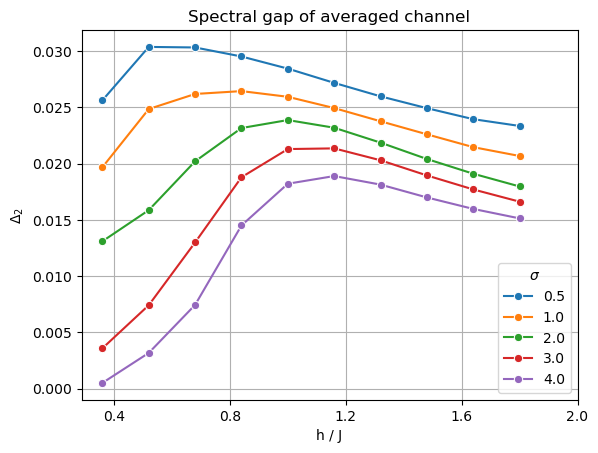

In [269]:
#ax = sns.barplot(data=ha_data, x="h_over_J", y="Delta2", hue="sigma", dodge=True, palette="tab10")
ax = sns.lineplot(data=ha_data, x="h_over_J", y="Delta2", hue="sigma", marker="o", palette="tab10")


ticks = ax.get_xticks()
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]

ax.set_xticks(ticks[1::2])
ax.set_xticklabels(labels[1::2])

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\Delta_2$")

ax.set_title("Spectral gap of averaged channel")
plt.legend(title=rf"$\sigma$")
plt.grid(True)
ax.figure.savefig("docu/gap"+suffix+".png", dpi=300, bbox_inches="tight")

'''
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]
ymin, ymax = 0., 0.05
pos=[[0,0],[0,1],[1,0],[1,1]]

fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)


for i, sigma in enumerate(ha_data["sigma"].unique()):
    ax = axs[pos[i][0], pos[i][1]]
    subset = ha_data[ha_data["sigma"] == sigma].sort_values("h_over_J")

    sns.barplot(data=subset, x="h_over_J", y="Delta2", ax=ax)

    ax.set_title(rf"$\sigma = {sigma}$")
    ax.set_xlabel("h / J")
    ax.set_ylabel(r"$\Delta_2$")
    ax.legend(title=r"$\sigma$")
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(ticks[1::2])
    ax.set_xticklabels(labels[1::2])
    plt.tight_layout()
plt.show()
'''

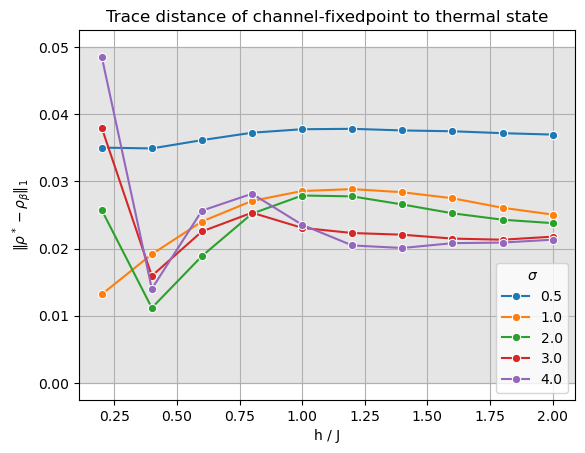

In [271]:
#ax = sns.barplot(data=ha_data, x="h_over_J", y="trace_distance", hue="sigma", dodge=True, palette="tab10")
ax = sns.lineplot(data=ha_data, x="h_over_J", y="trace_distance", hue="sigma", marker="o", palette="tab10")

ax.axhspan(0, 0.05, color="gray", alpha=0.2)

ticks = ax.get_xticks()
labels = [f"{v:.1f}" for v in sorted(ha_data["h_over_J"].unique())]

#ax.set_xticks(ticks[1::2])
#ax.set_xticklabels(labels[1::2])

ax.set_xlabel("h / J")
ax.set_ylabel(rf"$\|\rho^*-\rho_{{\beta}}\|_1$")
ax.set_title("Trace distance of channel-fixedpoint to thermal state")
plt.legend(title=rf"$\sigma$")
plt.grid(True)
ax.figure.savefig("docu/distance_to_gibbs"+suffix+".png", dpi=300, bbox_inches="tight")